# Test Multi-dimensional Fisher

1. At least reproduce the plots in `new_new_test.ipynb`.
2. Well, it works for multi-dimensions?

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import gwfast.network as network
import gwfast.waveforms as waveforms
from gwfast.gwfastGlobals import detectors as det_dict, detPath
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr, plot_corners

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:31: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

# H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

# H1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# L1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# V1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_GEN = network.DetNet({'H1': H1_GEN, 'L1': L1_GEN, 'V1': V1_GEN})

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [3]:
events = {
    'Mc':np.array([30, 30]), 'eta':np.array([0.24, 0.24]), 
    'chi1z':np.array([0.3, 0.3]), 'chi2z':np.array([0.5, 0.5]), 
    'iota':np.array([0.9*np.pi/2, 0.9*np.pi/2]), 'tcoal':np.array([0, 0]), 'phase':np.array([2, 2]), 'psi':np.array([1, 1]), 
    'R_orbit':np.array([20, 20]), 'M_lz':np.array([2e4, 2e4]), 'src_pos':np.array([0.5, 0.5]), 
    'dL':np.array([0.8, 0.8]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43])
}
events = {key: val.astype(np.float64) for key, val in events.items()}

In [4]:
SNR_AGN = HLV_AGN.SNR(events)
# SNR_GEN = HLV_GEN.SNR(events)
# SNR_BBH = HLV_BBH.SNR(events)
print("SNR with AGN lensing:", SNR_AGN)
# print("SNR with general lensing:", SNR_GEN)
# print("SNR without lensing:", SNR_BBH)

SNR with AGN lensing: [43.41096603 43.41096603]


Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


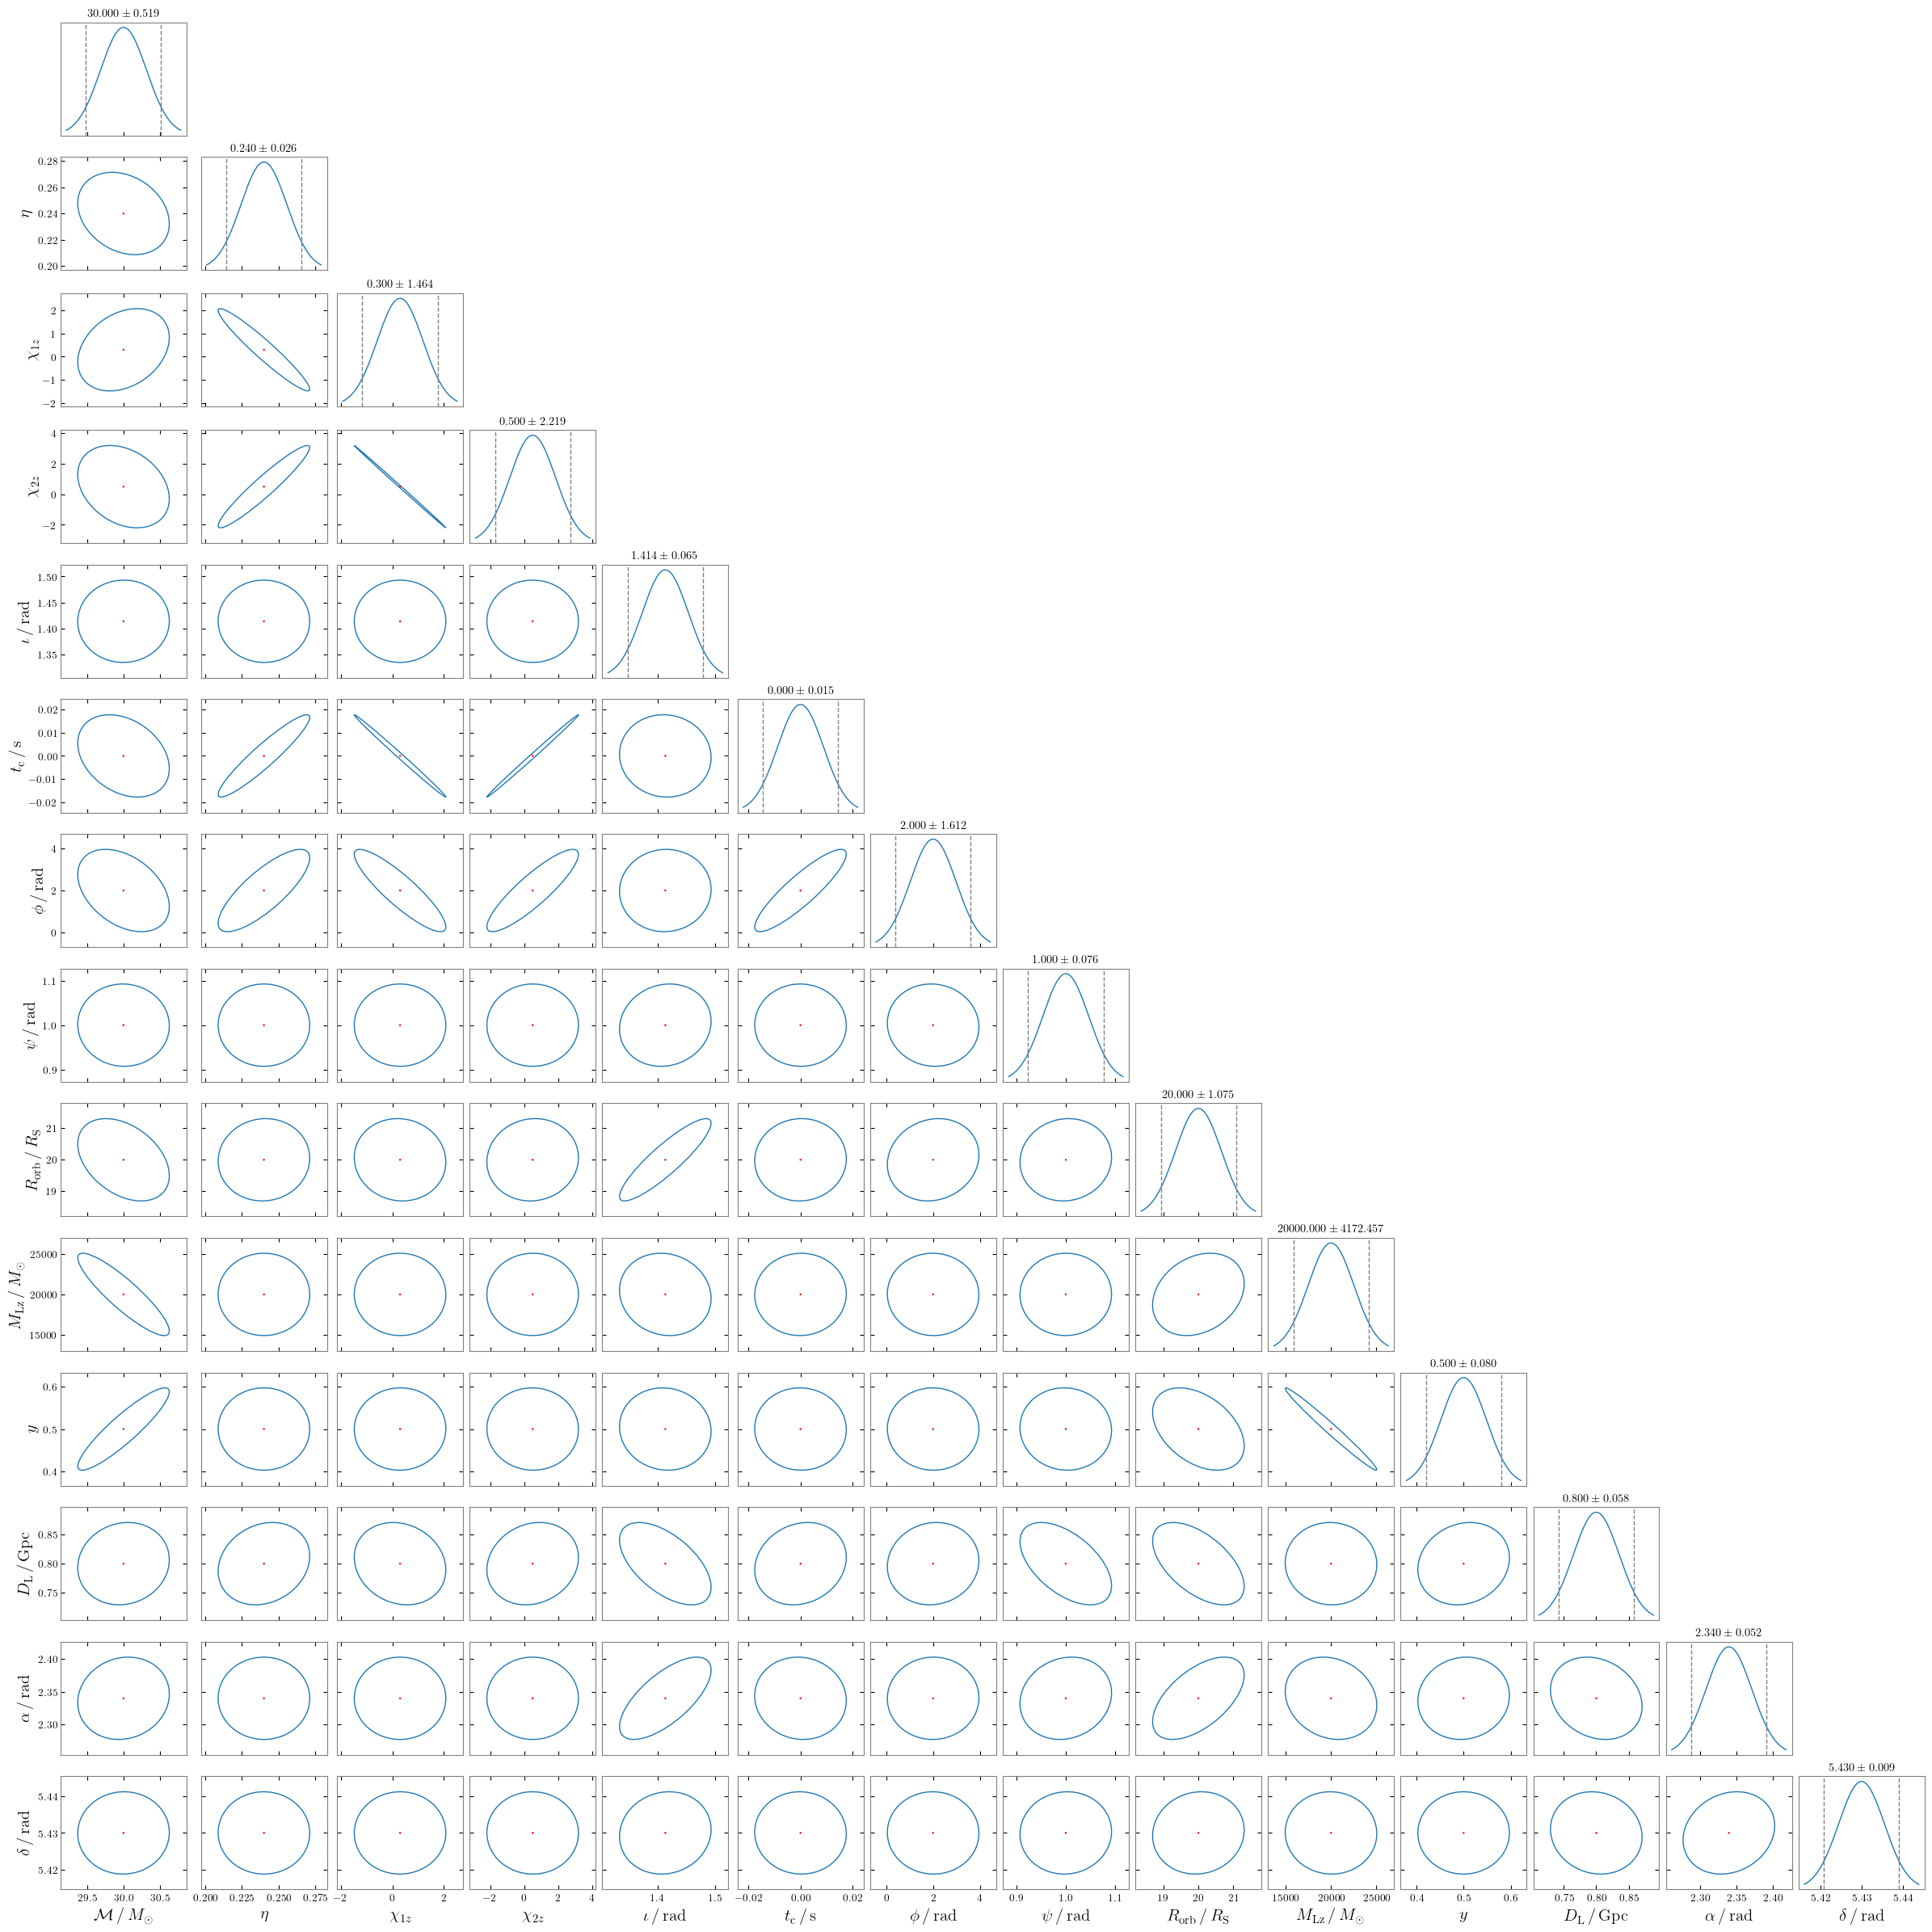

In [5]:
fisher_AGN = HLV_AGN.FisherMatr(events, res=1000)
keys = list(events.keys()).copy()
reduced_fisher_AGN, _ = reduce_Fisher_matrix(fisher_AGN, keys=keys)
reduced_fisher_AGN = np.array(reduced_fisher_AGN)
reduced_cov_AGN, ie = CovMatr(reduced_fisher_AGN)

idx = 0
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in events.items()}
labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}
fig = plot_corners(
    reduced_cov_AGN[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)

Yep, it is the same as the old one :)

## Test multidimension 

In [3]:
shape = (2, 3, 4)
noise = np.random.normal(loc=1, scale=0.1, size=shape)

inj_vals = {
    'Mc': 30, 'eta': 0.24,
    'chi1z': 0.3, 'chi2z': 0.5,
    'iota': 0.9*np.pi/2, 'tcoal': 0, 'phase': 2, 'psi': 1,
    'R_orbit': 50, 'M_lz': 2e4, 'src_pos': 0.5,
    'dL': 0.8, 'theta': 2.34, 'phi': 5.43
}

inj_params = {key: (val*noise).astype(np.float64) for key, val in inj_vals.items()}
fisher_AGN = HLV_AGN.FisherMatr(inj_params, res=100)

Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


In [4]:
keys = list(inj_params.keys()).copy()
reduced_fisher_AGN, _ = reduce_Fisher_matrix(fisher_AGN, keys=keys)
fisher_AGN.shape, reduced_fisher_AGN.shape

((14, 14, 2, 3, 4), (14, 14, 2, 3, 4))

It didnt crash, that's the whole point :)

In [13]:
total_size = np.product(fisher_AGN.shape)
n_nan = np.sum(np.isnan(fisher_AGN))
unique_entries = np.unique(fisher_AGN).size
print("Fisher matrix size:", total_size)
print("NaN entry size", n_nan)
print("Unique entries:", unique_entries)
print("Checksum:", total_size == unique_entries + n_nan - (1 if n_nan != 0 else 0))

# Try to check the number of unique entries in the matrix, but then the matrix is symmetric in the first two axes, a bit hard to actually calculate the correct checksum.

Fisher matrix size: 4704
NaN entry size 196
Unique entries: 2416
Checksum: False


In [12]:
np.unique(fisher_AGN, return_counts=True)

(array([-1.52777208e+08, -1.37463301e+08, -1.12628499e+08, ...,
         2.31772690e+09,  3.49902538e+09,             nan]),
 array([  2,   2,   2, ...,   1,   1, 196]))

## Numpy broadcasting tests

In [ ]:
arrA = np.ones((10))
arrB = np.ones((10, 100))

arrA * arrB

ValueError: operands could not be broadcast together with shapes (10,) (10,100) 

In [ ]:
freq_grid = np.arange(24).reshape((4, 2, 3))
print("Before transform:\n", freq_grid)  # Check the order first

_freq_grid = np.moveaxis(freq_grid, 0, -1)
print("Swapped freq. axis:\n", _freq_grid)  # Check the order after moveaxis
flat_freq_grid = _freq_grid.reshape((-1, _freq_grid.shape[-1]))
print("After transform:\n", flat_freq_grid)  
print("The parameters:\n", freq_grid[0].reshape(-1))

print("Reconstructed matrix:\n", flat_freq_grid.reshape(*_freq_grid.shape))

Before transform:
 [[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]

 [[12 13 14]
  [15 16 17]]

 [[18 19 20]
  [21 22 23]]]
Swapped freq. axis:
 [[[ 0  6 12 18]
  [ 1  7 13 19]
  [ 2  8 14 20]]

 [[ 3  9 15 21]
  [ 4 10 16 22]
  [ 5 11 17 23]]]
After transform:
 [[ 0  6 12 18]
 [ 1  7 13 19]
 [ 2  8 14 20]
 [ 3  9 15 21]
 [ 4 10 16 22]
 [ 5 11 17 23]]
The parameters:
 [0 1 2 3 4 5]
Reconstructed matrix:
 [[[ 0  6 12 18]
  [ 1  7 13 19]
  [ 2  8 14 20]]

 [[ 3  9 15 21]
  [ 4 10 16 22]
  [ 5 11 17 23]]]


In [ ]:
jac_mat = np.arange(24).reshape((4, 2, 3)) + 1j * np.random.rand(4, 2, 3)
print(np.expand_dims(jac_mat, 2).shape)  
print(jac_mat.transpose((1, 0, 2)).shape)
_result = (np.expand_dims(jac_mat, 2).conj() * jac_mat.transpose((1, 0, 2)))
result = np.swapaxes(_result, 1, 2)
print(result.shape)

(4, 2, 1, 3)
(2, 4, 3)
(4, 4, 2, 3)


In [ ]:
result2 = np.expand_dims(jac_mat, 1).conj() * jac_mat
print(result2.shape)

(4, 4, 2, 3)


In [ ]:
np.all(result == result2)

True

In [ ]:
np.unique(result).size, 4 * 2 * 3 * 4

(96, 96)

In [ ]:
freq_grid.shape, freq_grid.T.shape

((4, 2, 3), (3, 2, 4))

## Okay, there is `mpmath`...

Does it work with high dimension array?

In [2]:
import mpmath as mpm

In [7]:
arr_3d = np.arange(12).reshape((2, 2, 3))

mpm.matrix(arr_3d[0].astype(np.float64))

matrix(
[['0.0', '1.0', '2.0'],
 ['3.0', '4.0', '5.0']])